# Analiza EEG OpenSignals

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch, spectrogram
import h5py
import os
import glob

In [ ]:
# Tworzy słownik przechowujący graniczne częstotliwości dla poszczególnych biologicznych rytmów fal mózgowych EEG.
bands = {'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30), 'gamma': (30, 40)}

# Definiuje funkcję, która filtruje sygnał, odrzucając częstotliwości spoza zadanego przedziału lowcut i highcut.
def bandpass_filter(signal, fs, lowcut=1, highcut=40, order=4):
    nyq = fs / 2  # Oblicza częstotliwość Nyquista, która stanowi połowę wartości częstotliwości próbkowania sygnału.
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')  # Generuje współczynniki matematyczne b oraz a dla cyfrowego filtru Butterwortha.
    return filtfilt(b, a, signal)  # Przeprowadza dwukrotną filtrację sygnału w przód i w tył, aby zapobiec przesunięciom w fazie.

FOLDER_PATH = "."  # Definiuje zmienną przechowującą ścieżkę do folderu roboczego, w którym znajdują się pliki z pomiarami.

files_h5 = glob.glob(os.path.join(FOLDER_PATH, "*.h5"))  # Przeszukuje folder i zapisuje na liście ścieżki do wszystkich znalezionych plików z rozszerzeniem .h5.
files_txt = glob.glob(os.path.join(FOLDER_PATH, "*.txt"))  # Przeszukuje folder i zapisuje na liście ścieżki do wszystkich plików tekstowych z rozszerzeniem .txt.
all_files = files_h5 + files_txt  # Łączy obie listy w jedną wspólną listę zawierającą wszystkie pliki przeznaczone do analizy.

summary_data = []  # Inicjalizuje pustą listę, która będzie zbierać końcowe wyniki obliczeń dla każdego przetworzonego pliku.

print(f"Znaleziono {len(all_files)} plików do analizy.")

Znaleziono 16 plików do analizy.



--- Przetwarzanie pliku: Dawid_EEG_Pomiar_2026-06-02_13-13-32.h5 ---
Liczba próbek: 68400, Częstotliwość próbkowania: 1000 Hz


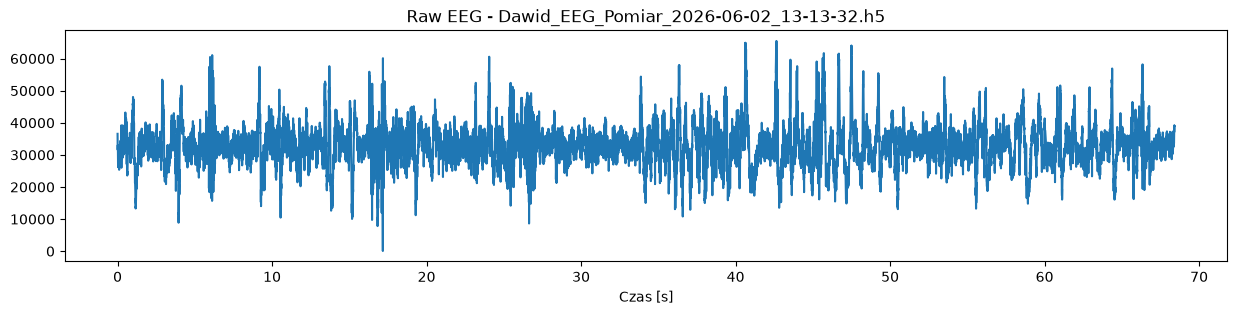

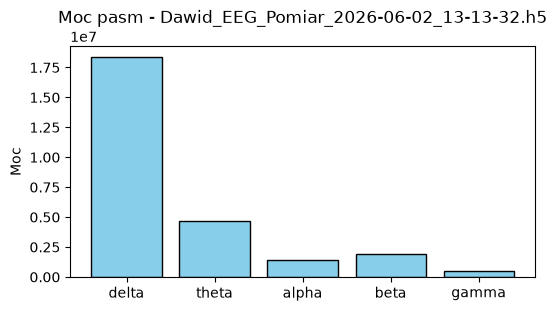

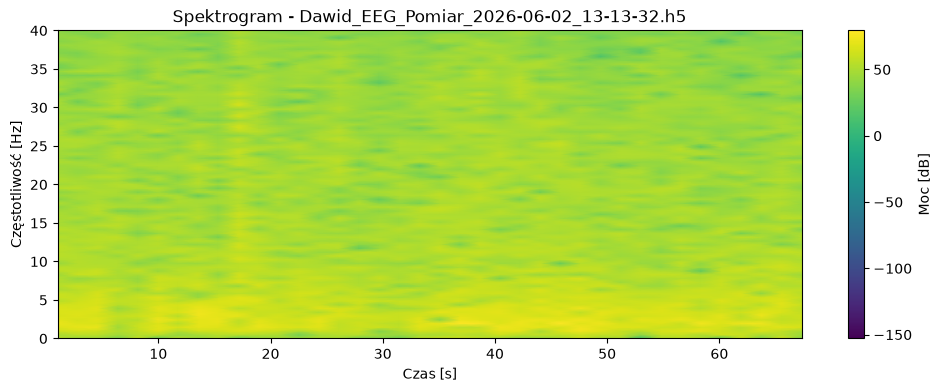


--- Przetwarzanie pliku: Dawid_EEG_Słuchawki_2026-06-02_13-15-17.h5 ---
Liczba próbek: 87450, Częstotliwość próbkowania: 1000 Hz


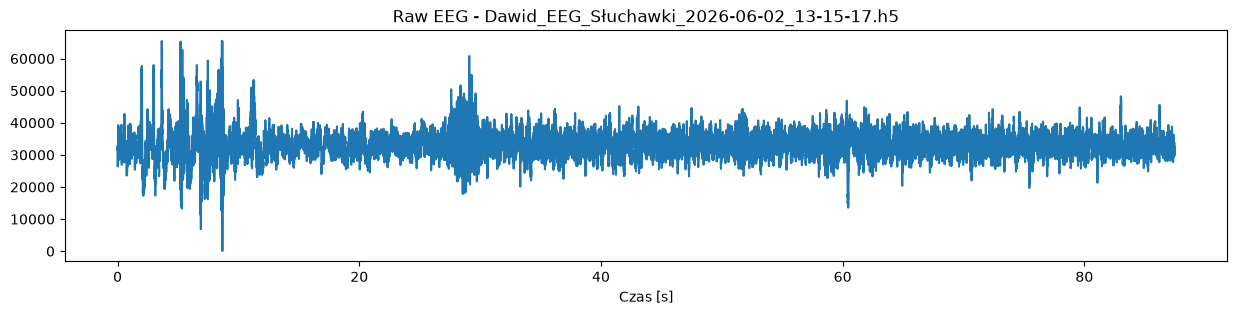

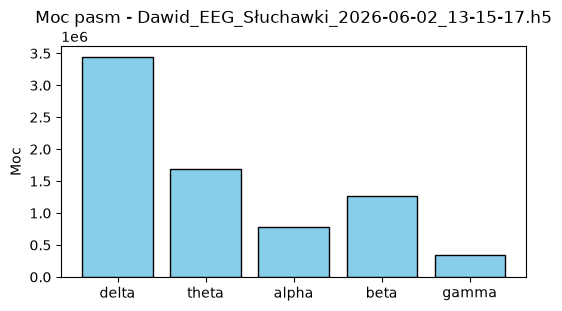

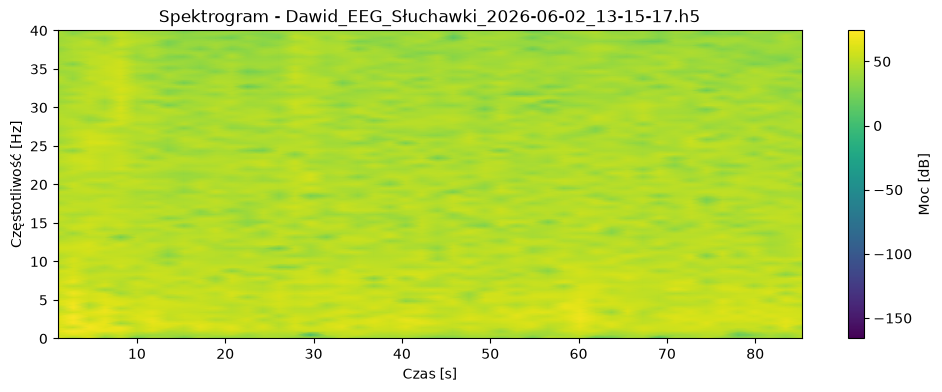


--- Przetwarzanie pliku: Janek_EEG_2026-06-02_13-07-14.h5 ---
Liczba próbek: 65550, Częstotliwość próbkowania: 1000 Hz


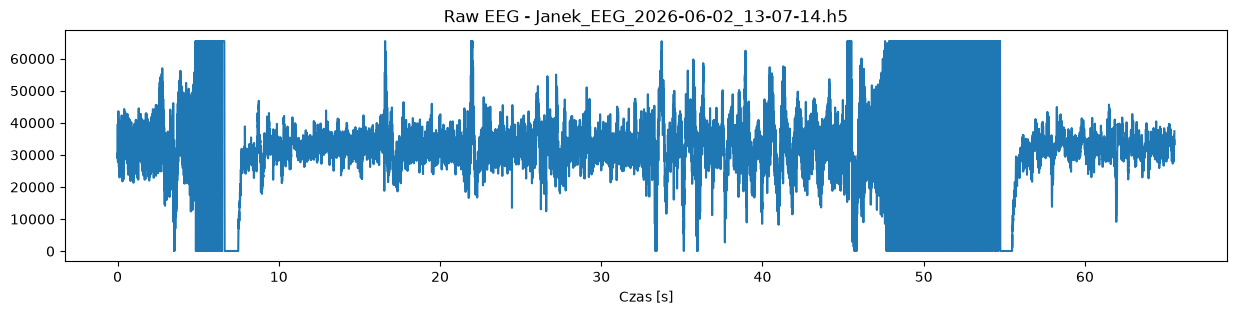

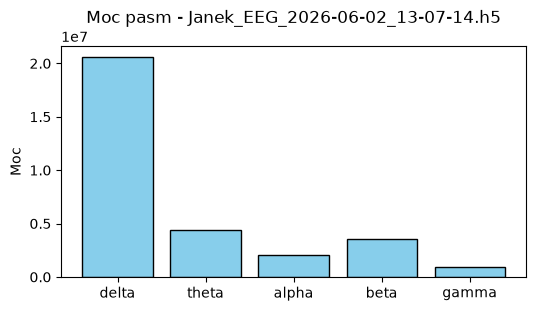

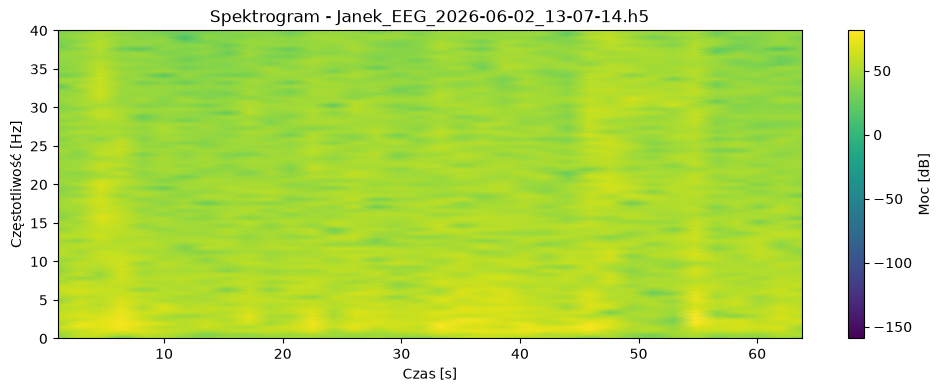


--- Przetwarzanie pliku: Janek_EEG_Słuchawki_2026-06-02_13-09-10.h5 ---
Liczba próbek: 73500, Częstotliwość próbkowania: 1000 Hz


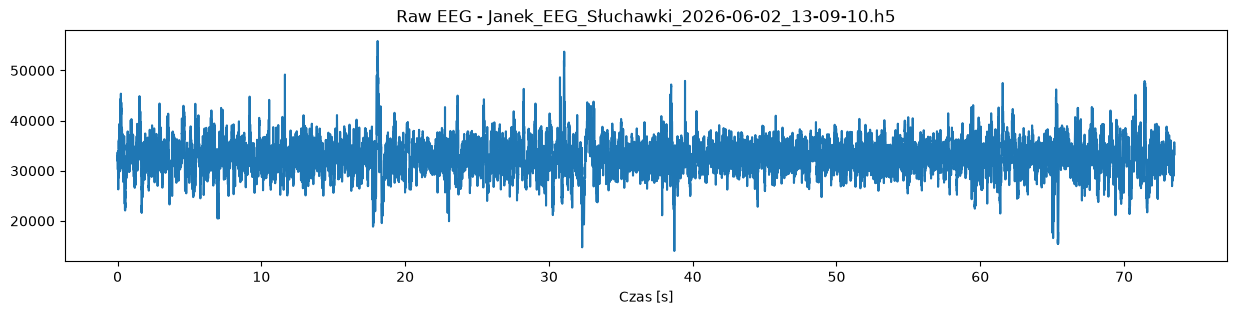

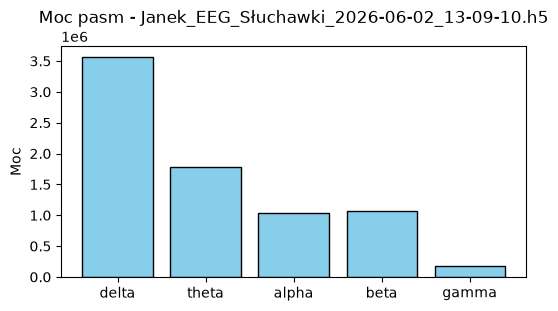

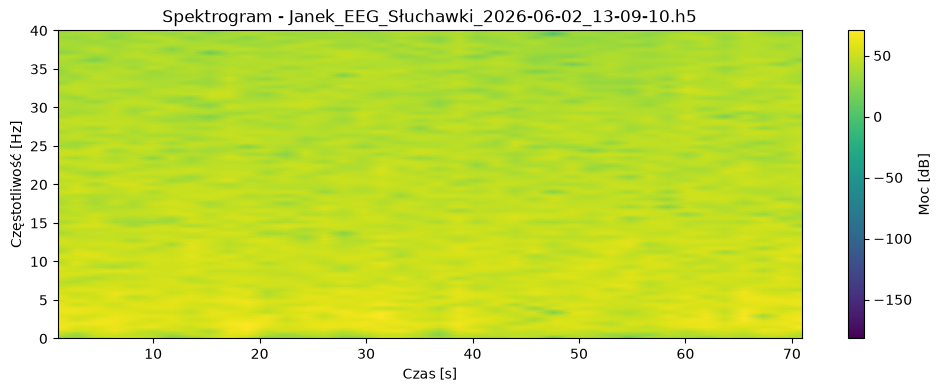


--- Przetwarzanie pliku: Janek_EEG_Słuchawki_ZamknięteOczy_2026-06-02_13-11-04.h5 ---
Liczba próbek: 54300, Częstotliwość próbkowania: 1000 Hz


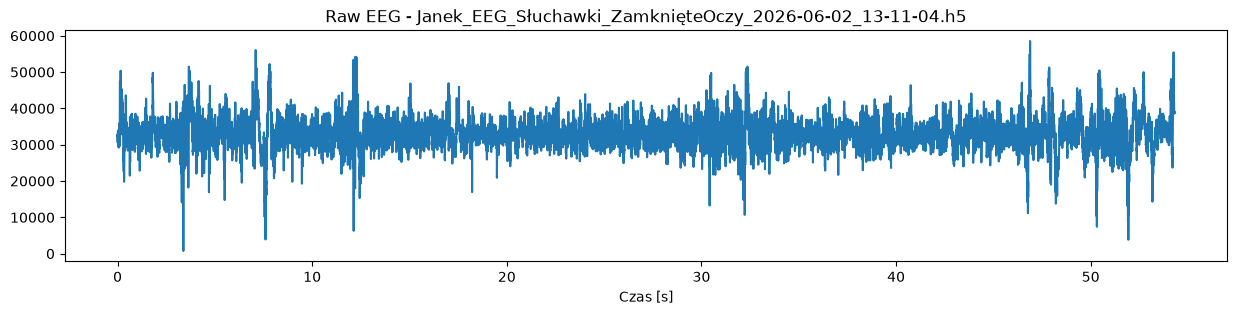

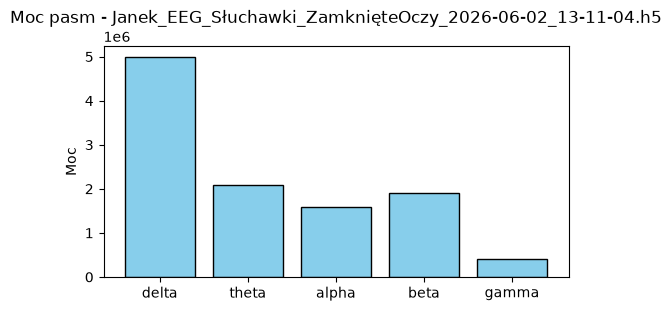

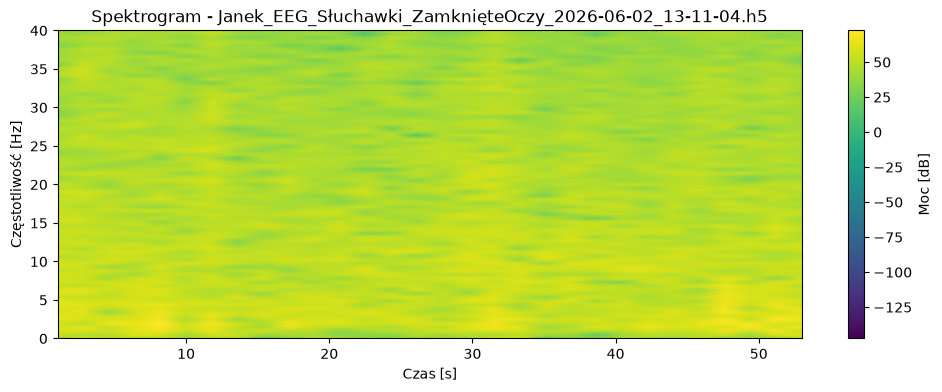


--- Przetwarzanie pliku: Sergiusz_EEG_2026-06-02_12-57-21.h5 ---
Liczba próbek: 67500, Częstotliwość próbkowania: 1000 Hz


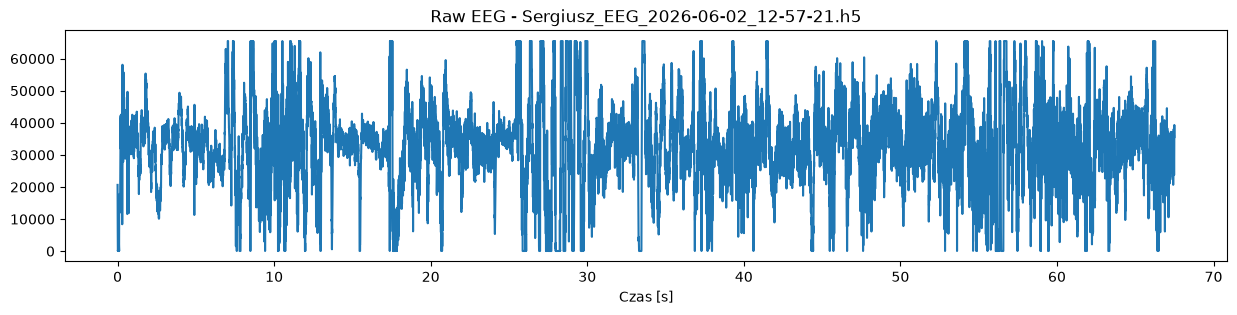

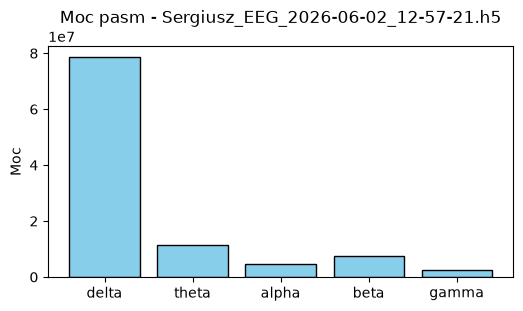

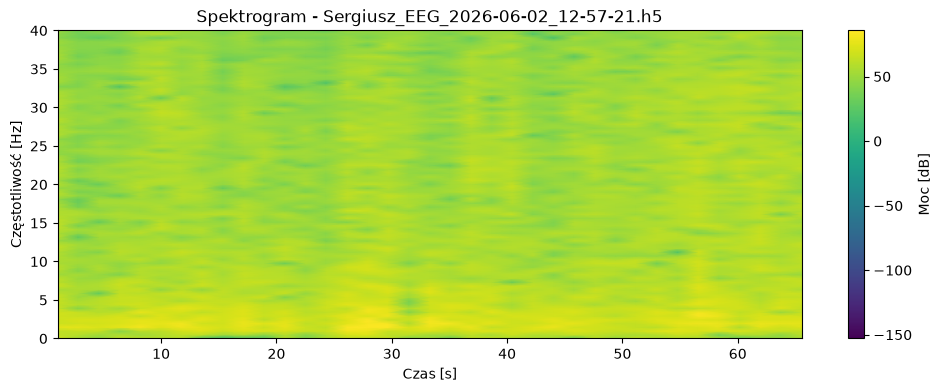


--- Przetwarzanie pliku: Sergiusz_EEG_Pomiar_2026-06-02_13-01-29.h5 ---
Liczba próbek: 54000, Częstotliwość próbkowania: 1000 Hz


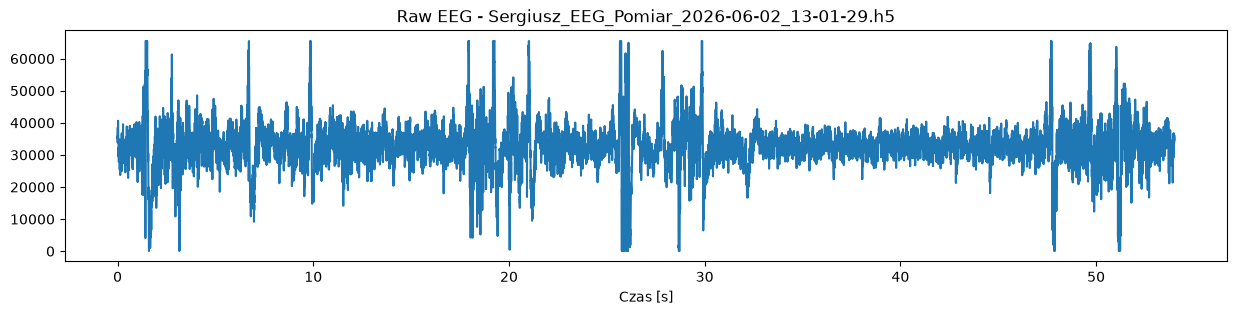

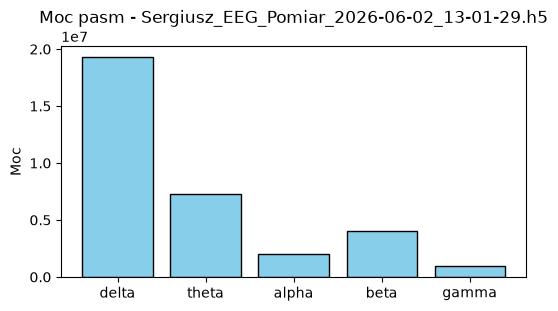

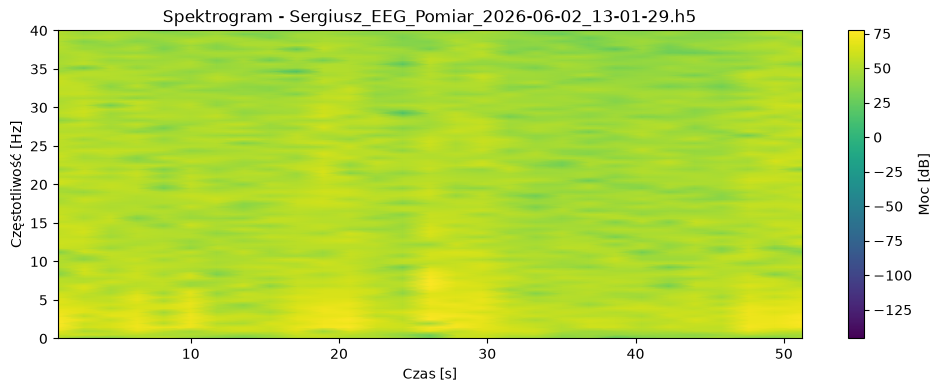


--- Przetwarzanie pliku: Sergiusz_EEG_Słuchawki_2026-06-02_13-04-38.h5 ---
Liczba próbek: 52050, Częstotliwość próbkowania: 1000 Hz


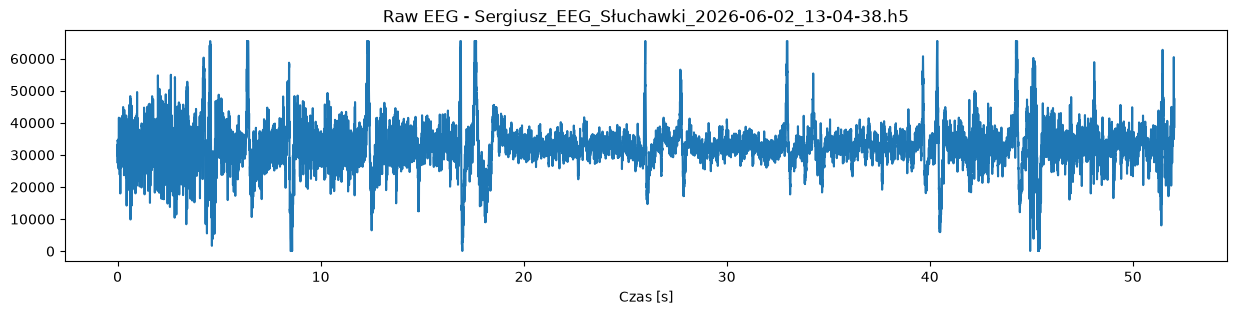

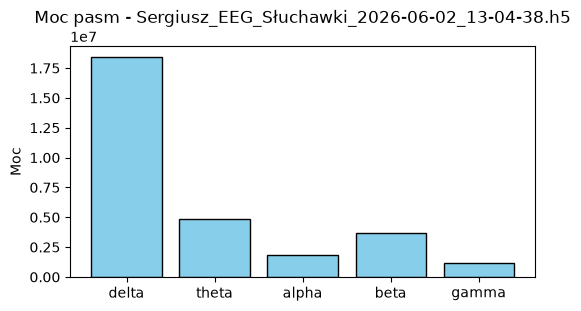

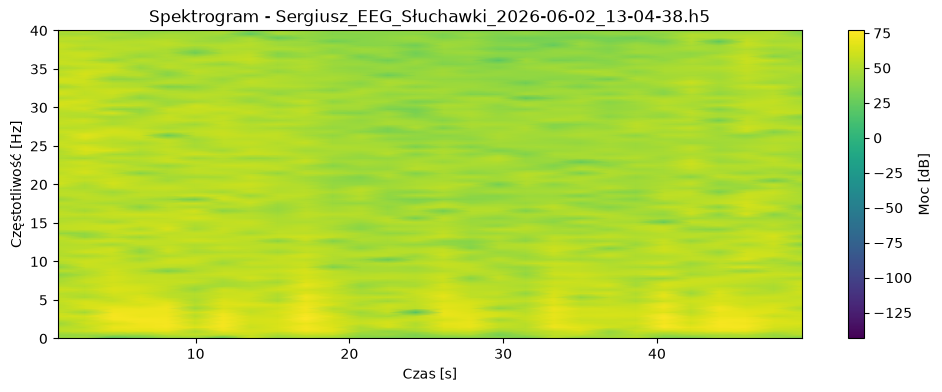


--- Przetwarzanie pliku: Dawid_EEG_Pomiar_2026-06-02_13-13-32.txt ---
Liczba próbek: 68400, Częstotliwość próbkowania: 1000 Hz


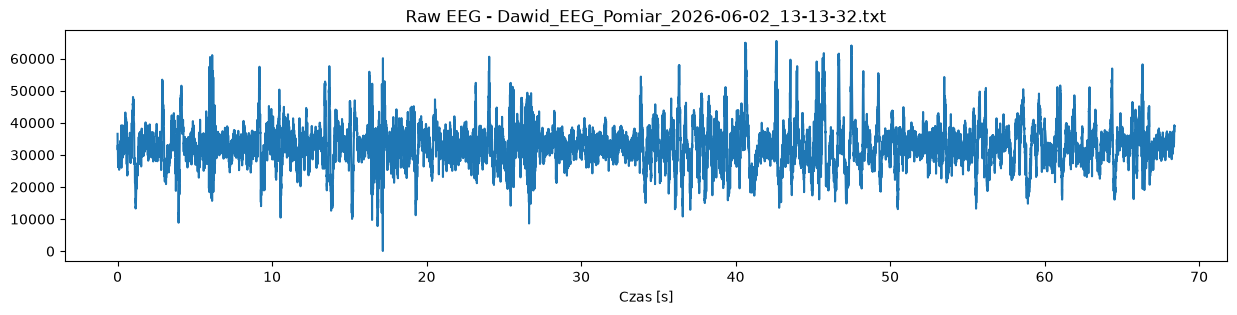

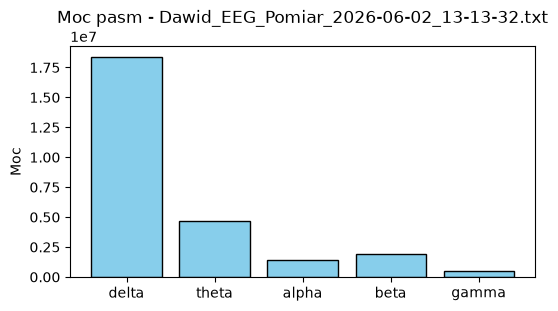

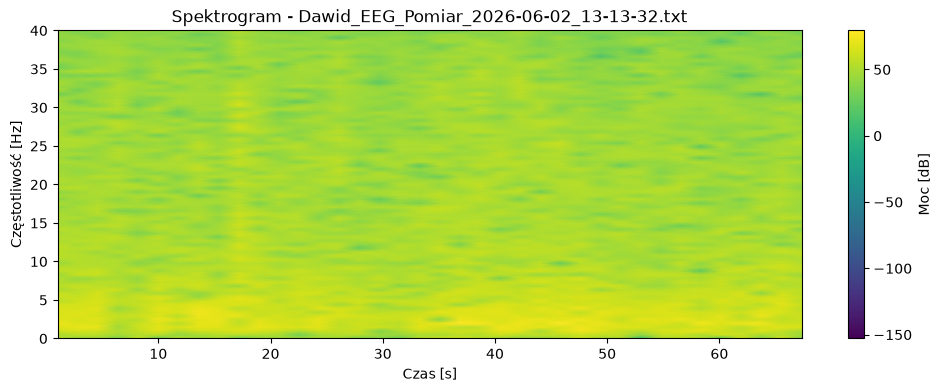


--- Przetwarzanie pliku: Dawid_EEG_Słuchawki_2026-06-02_13-15-17.txt ---
Liczba próbek: 87450, Częstotliwość próbkowania: 1000 Hz


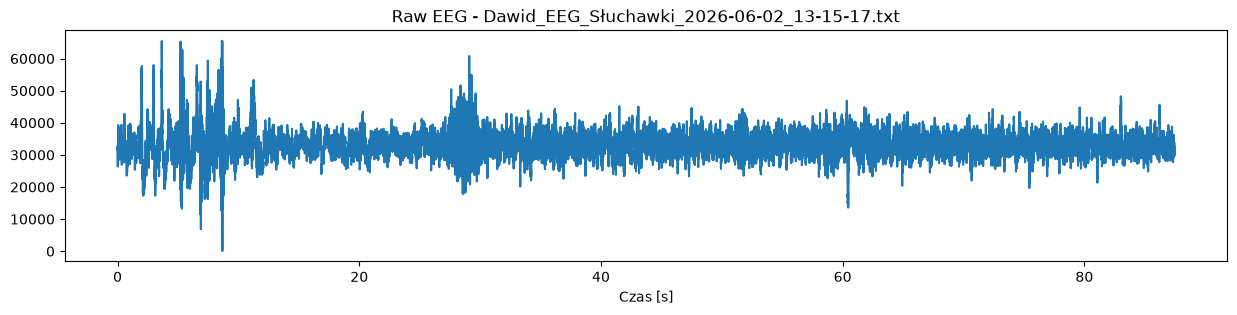

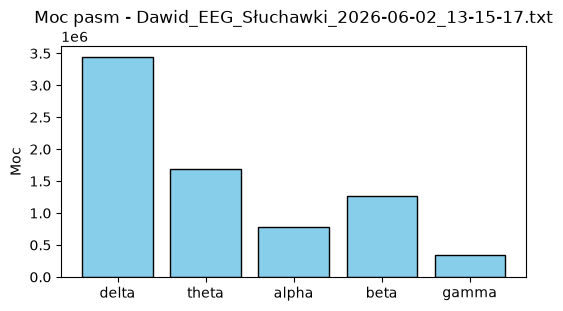

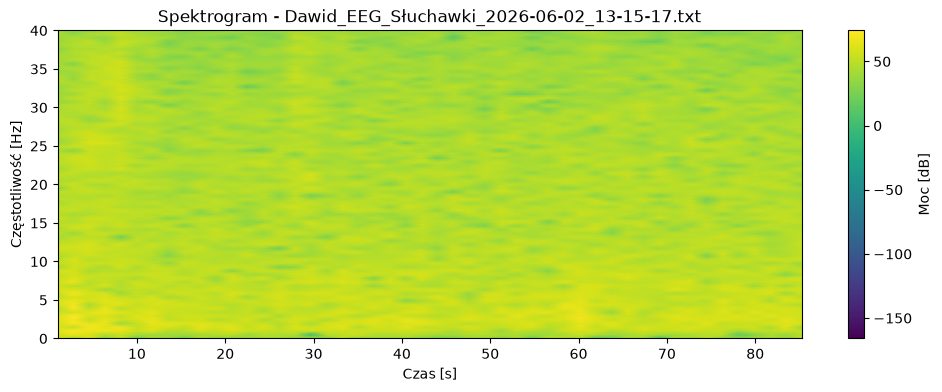


--- Przetwarzanie pliku: Janek_EEG_2026-06-02_13-07-14.txt ---
Liczba próbek: 65550, Częstotliwość próbkowania: 1000 Hz


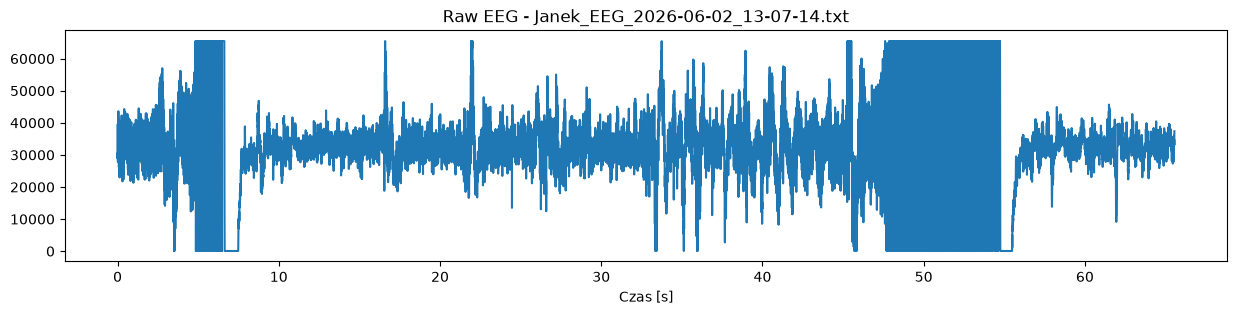

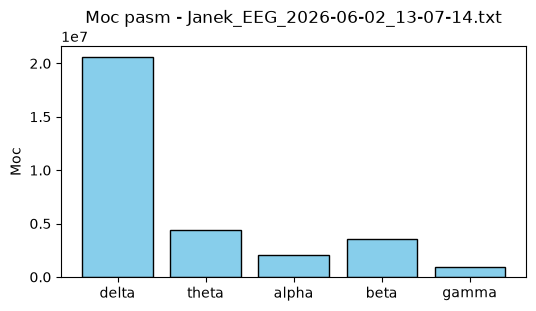

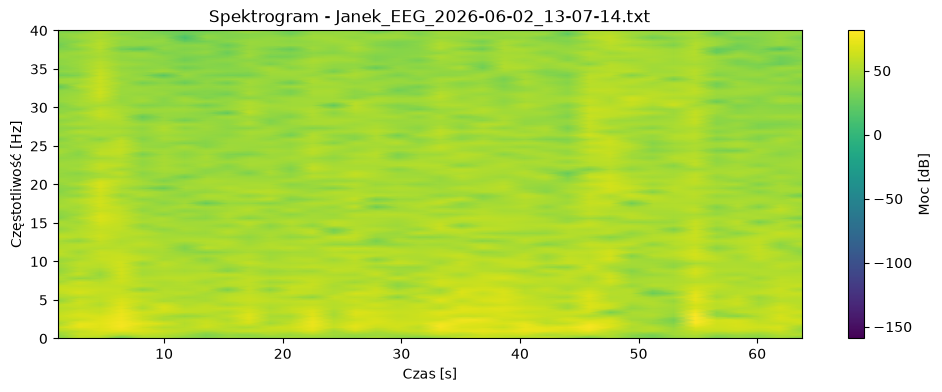


--- Przetwarzanie pliku: Janek_EEG_Słuchawki_2026-06-02_13-09-10.txt ---
Liczba próbek: 73500, Częstotliwość próbkowania: 1000 Hz


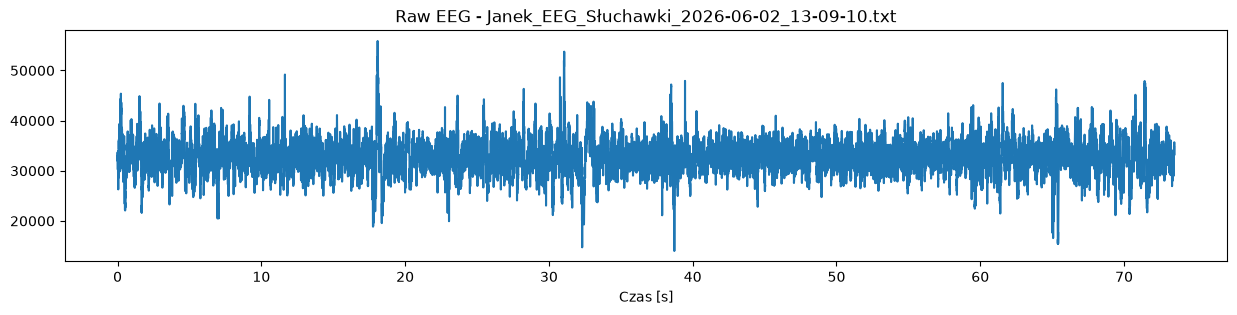

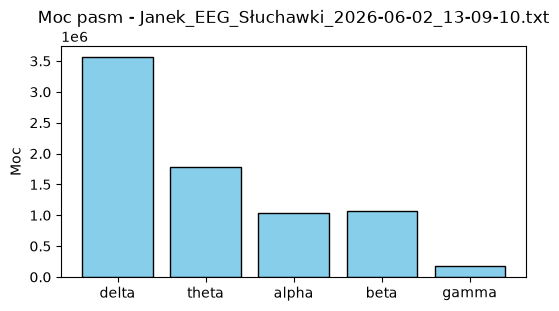

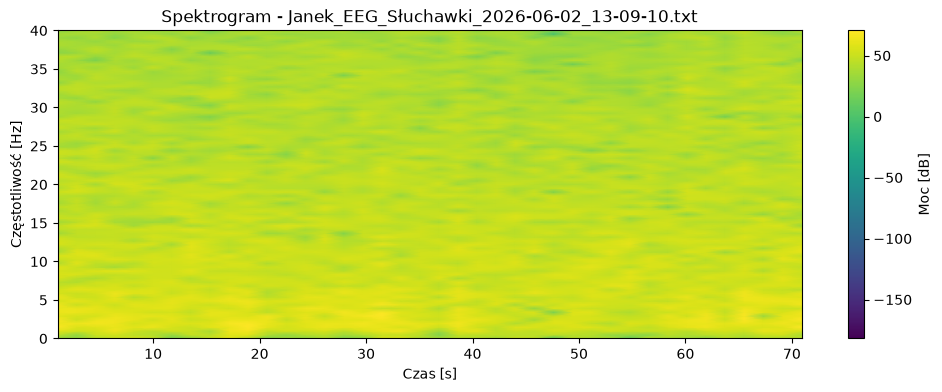


--- Przetwarzanie pliku: Janek_EEG_Słuchawki_ZamknięteOczy_2026-06-02_13-11-04.txt ---
Liczba próbek: 54300, Częstotliwość próbkowania: 1000 Hz


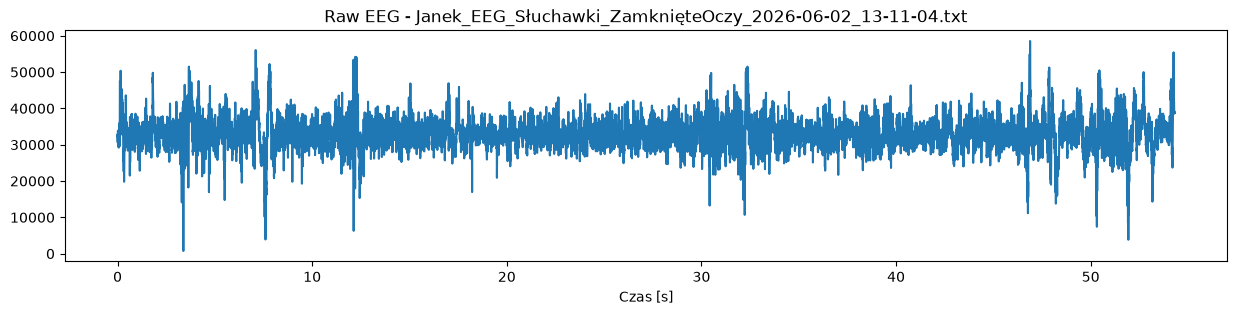

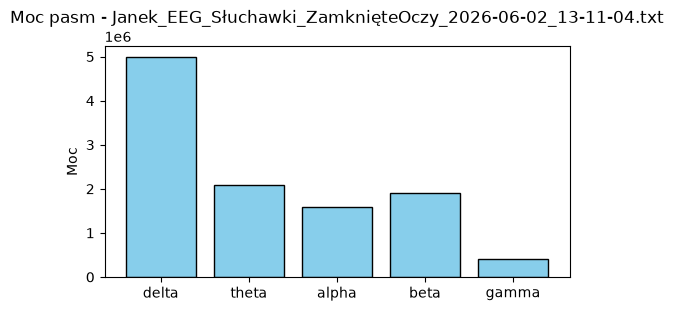

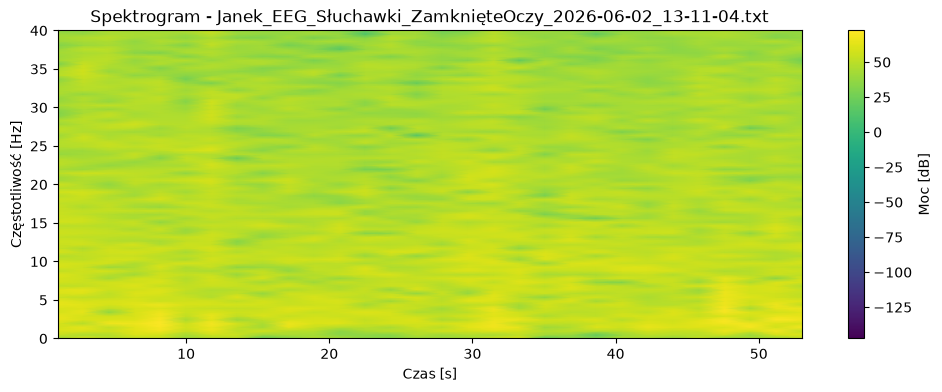


--- Przetwarzanie pliku: Sergiusz_EEG_2026-06-02_12-57-21.txt ---
Liczba próbek: 67500, Częstotliwość próbkowania: 1000 Hz


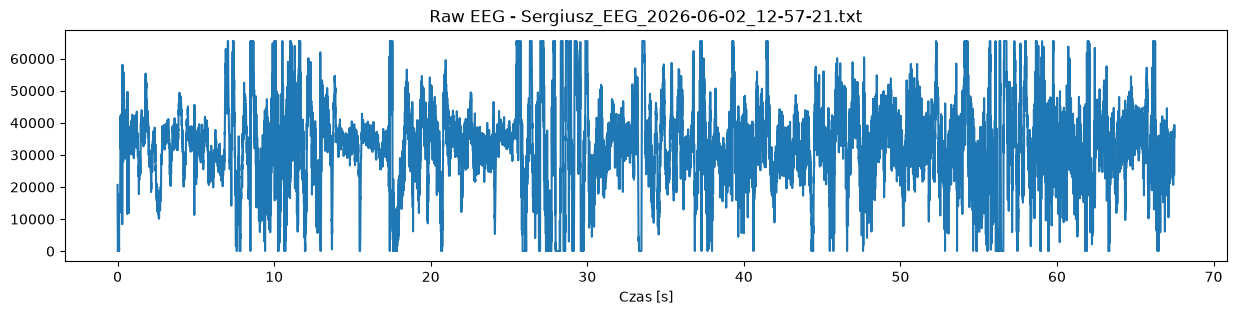

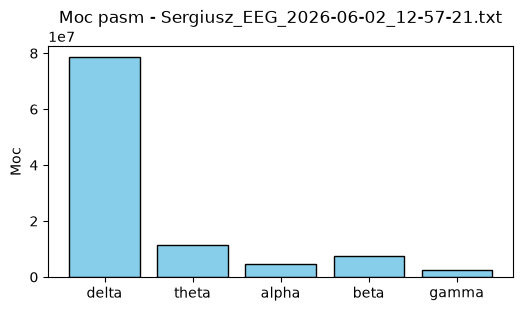

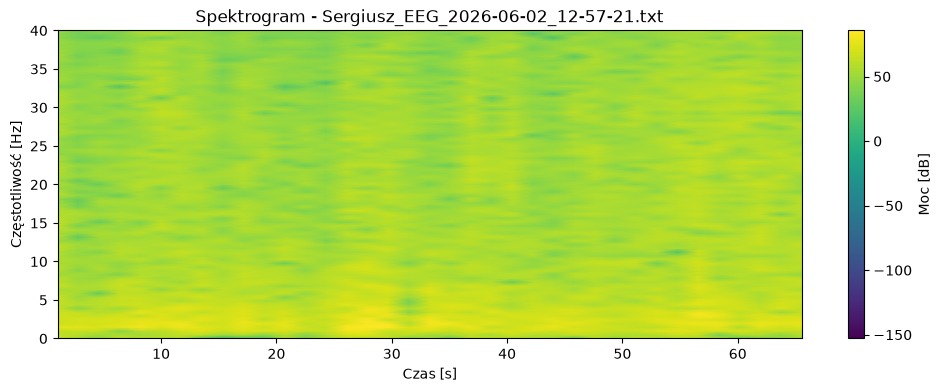


--- Przetwarzanie pliku: Sergiusz_EEG_Pomiar_2026-06-02_13-01-29.txt ---
Liczba próbek: 54000, Częstotliwość próbkowania: 1000 Hz


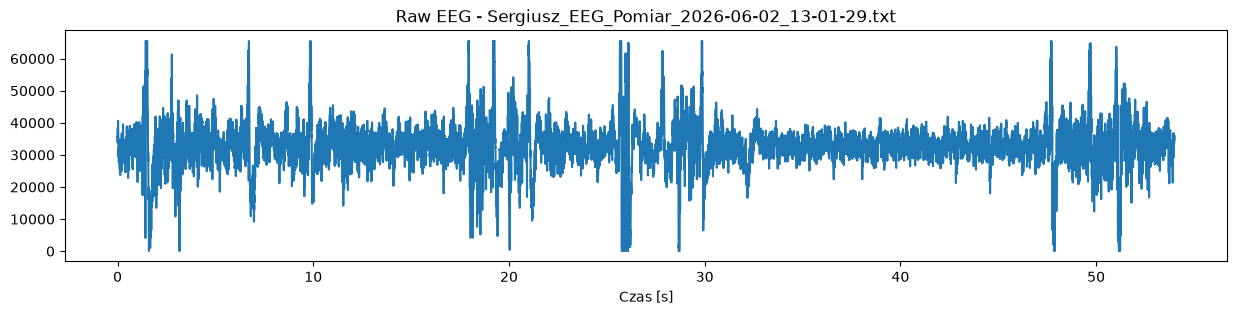

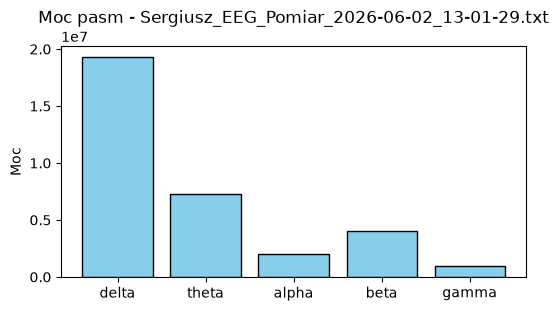

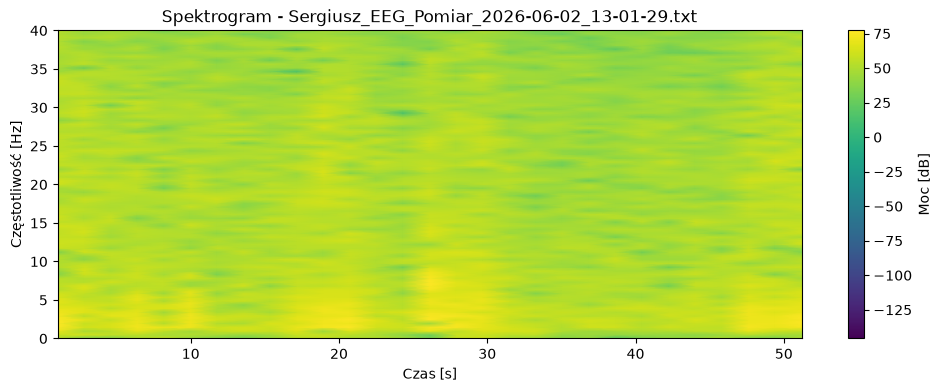


--- Przetwarzanie pliku: Sergiusz_EEG_Słuchawki_2026-06-02_13-04-38.txt ---
Liczba próbek: 52050, Częstotliwość próbkowania: 1000 Hz


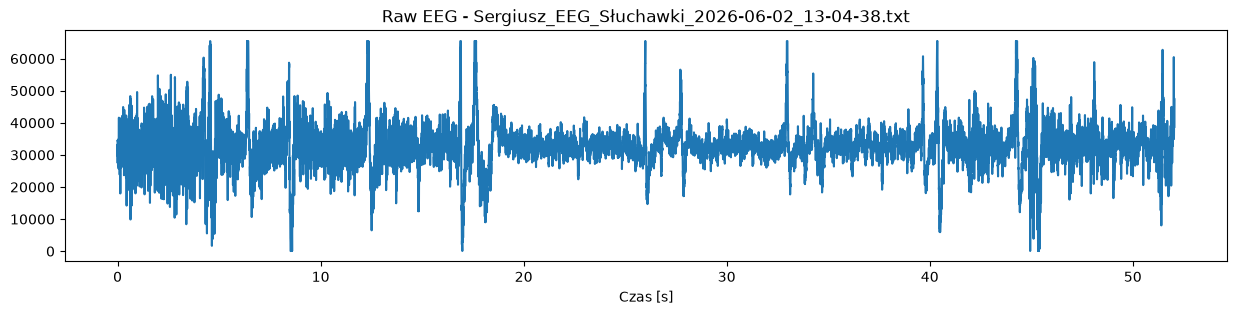

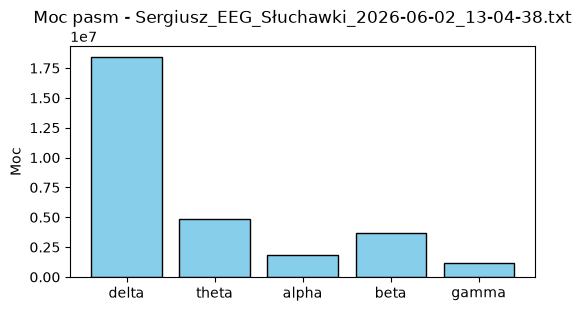

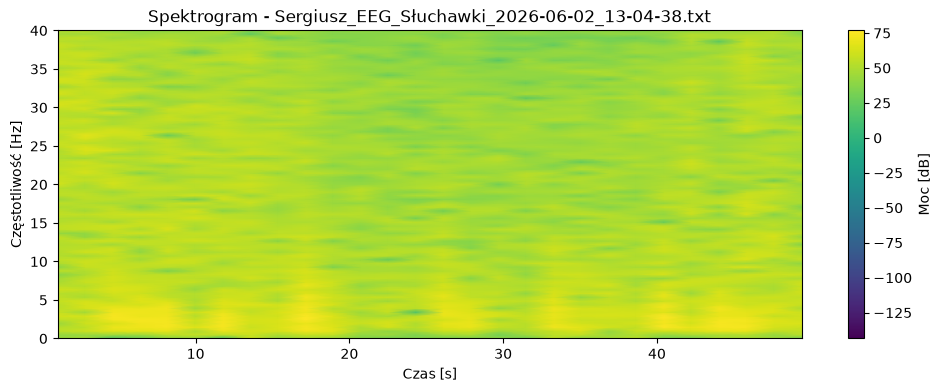

In [ ]:
for file_path in all_files:  # Rozpoczyna pętlę, która po kolei pobiera ścieżkę do każdego pliku z listy all_files.
    file_name = os.path.basename(file_path)  # Wyciąga samą nazwę pliku z jego pełnej ścieżki dostępu na dysku.
    print(f"\n--- Przetwarzanie pliku: {file_name} ---")  # aktualnie analizowany plik
    
    try:
        if file_path.endswith('.h5'):  # Sprawdza warunkiem if, czy aktualnie przetwarzany plik ma format hierarchiczny .h5.
            with h5py.File(file_path, 'r') as f:  # Otwiera bezpiecznie plik .h5 w trybie tylko do odczytu pod lokalną zmienną f.
                device = list(f.keys())[0]  # Pobiera nazwę głównego klucza w pliku HDF5, która odpowiada nazwie użytego urządzenia.
                eeg = f[f'{device}/raw/channel_1'][:].flatten()  # Wczytuje surowe dane z kanału pierwszego i spłaszcza je do jednowymiarowego wektora.
                fs = int(f[device].attrs['sampling rate'])  # Odczytuje wartość częstotliwości próbkowania zapisaną w atrybutach nagłówka pliku i zamienia ją na liczbę całkowitą.
                
        elif file_path.endswith('.txt'):  # Jeśli plik nie jest formatu .h5, sprawdza warunkiem elif, czy plik posiada rozszerzenie tekstowe .txt.
            data = np.loadtxt(file_path, comments='#')  # Wczytuje dane numeryczne z pliku tekstowego, ignorując linie komentarza zaczynające się od znaku krzyżyka.
            eeg = data[:, -1]  # Pobiera wartości z ostatniej kolumny wczytanej macierzy, przyjmując ją jako rejestrację sygnału EEG.
            fs = 1000  # Przypisuje sztywną wartość częstotliwości próbkowania równą 1000 Hz, zgodną ze standardem OpenSignals dla plików tekstowych.
            
        t = np.arange(len(eeg)) / fs  # Tworzy wektor czasu poprzez wygenerowanie indeksów próbek i podzielenie ich przez częstotliwość próbkowania.
        print(f"Liczba próbek: {len(eeg)}, Częstotliwość próbkowania: {fs} Hz")  # Drukuje na ekranie podstawowe informacje o rozmiarze sygnału i parametrach rejestracji.
        
        plt.figure(figsize=(15, 3))  # Tworzy nowe okno wykresu o określonych proporcjach szerokości do wysokości.
        plt.plot(t, eeg)  # Rysuje surowy sygnał EEG, gdzie oś X to utworzony czas, a oś Y to amplituda mikrovoltów.
        plt.title(f'Raw EEG - {file_name}')  # Ustawia tytuł wykresu zwierający nazwę aktualnie rysowanego pliku pomiarowego.
        plt.xlabel('Czas [s]')  # Dodaje do wykresu etykietę opisującą oś poziomą jako czas wyrażony w sekundach.
        plt.show()  # Renderuje i wyświetla gotowy wykres surowego sygnału na ekranie monitora.
        
        eeg_filt = bandpass_filter(eeg, fs)  # Wywołuje wcześniej zdefiniowaną funkcję filtrującą w celu oczyszczenia surowego sygnału EEG.
        
        nperseg_welch = min(4096, len(eeg_filt))  # Ustala optymalny rozmiar okna dla metody Welcha, zapobiegając błędom przy zbyt krótkich sygnałach.
        freqs, psd = welch(eeg_filt, fs=fs, nperseg=nperseg_welch)  # Oblicza gęstość widmową mocy sygnału za pomocą uśrednionej metody Welcha.
        
        band_power = {}  # Tworzy pusty słownik przeznaczony na przechowanie obliczonych mocy dla poszczególnych pasm częstotliwości.
        for n, (l, h) in bands.items():  # Pętla przechodząca przez nazwy pasm oraz ich granice zdefiniowane w słowniku bands.
            idx = (freqs >= l) & (freqs < h)  # Tworzy maskę logiczną wybierającą tylko te częstotliwości z widma, które należą do danego pasma.
            band_power[n] = np.trapezoid(psd[idx], freqs[idx])  # Oblicza moc pasma poprzez całkowanie numeryczne wyciętego fragmentu widma metodą trapezów.
            
        alpha_theta_ratio = band_power['alpha'] / band_power['theta']  # Dzieli moc pasma alpha przez moc pasma theta w celu wyznaczenia wskaźnika relaksu.
        
        file_results = {'Nazwa pliku': file_name}  # Inicjalizuje słownik wynikowy dla bieżącego pliku, przypisując mu jego nazwę jako pierwszą cechę.
        file_results.update(band_power)  # Dołącza obliczone wartości mocy wszystkich pięciu pasm częstotliwości do słownika wynikowego.
        file_results['alpha_theta_ratio'] = alpha_theta_ratio  # Zapisuje obliczony przed chwilą wskaźnik proporcji alpha/theta jako kolejną kolumnę danych.
        summary_data.append(file_results)  # Wrzuca kompletny słownik z wynikami bieżącego pliku na ogólną listę zbiorczą summary_data.
        
        plt.figure(figsize=(6, 3))  # Inicjalizuje małe okno wykresu dedykowane dla wizualizacji struktury pasmowej.
        plt.bar(band_power.keys(), band_power.values(), color='skyblue', edgecolor='black')  # Rysuje wykres słupkowy prezentujący wartości mocy zapisane w słowniku band_power.
        plt.title(f'Moc pasm - {file_name}')  # Przypisuje wykresowi słupkowemu nagłówek z nazwą analizowanego pliku.
        plt.ylabel('Moc')  # Wartość reprezentująca obliczoną moc sygnału.
        plt.show()  # Wykres słupkowy dystrybucji mocy pasm.
        
        nperseg_spec = min(2048, len(eeg_filt))  # Dobiera bezpieczną szerokość okna czasowego dla obliczeń spektrogramu krótkoczasowego.
        f_spec, t_spec, Sxx = spectrogram(eeg_filt, fs, nperseg=nperseg_spec)  # Wyznacza spektrogram sygnału, zwracając macierz gęstości widmowej w funkcji czasu i częstotliwości.
        plt.figure(figsize=(12, 4))  # Otwiera szerokie okno wykresu dostosowane do czytelnego wyświetlania mapy dwuwymiarowej.
        plt.pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx), shading='gouraud')  # Tworzy kolorową mapę spektrogramu, zamieniając wartości mocy na skalę decybelową.
        plt.ylim(0, 40)  # Ogranicza oś pionową widoku spektrogramu do zakresu od 0 do 40 Hz, ponieważ tam znajdują się rytmy EEG.
        plt.title(f'Spektrogram - {file_name}')  # Nadaje wykresowi dwuwymiarowemu tytuł powiązany z bieżącym plikiem.
        plt.ylabel('Częstotliwość [Hz]')  # Opisuje oś pionową wykresu jako częstotliwość podaną w Hercach.
        plt.xlabel('Czas [s]')  # czas trwania badania wyrażony w sekundach.
        plt.colorbar(label='Moc [dB]')  # Skala natężenia mocy w decybelach.
        plt.show()  # Prezentuje gotowy spektrogram czasowo-częstotliwościowy w oknie programu.
        
    except Exception as e: #Błąd
        print(f"Błąd podczas analizy pliku {file_name}: {e}")


ZBIORCZE PODSUMOWANIE DLA WSZYSTKICH PLIKÓW


,delta,theta,alpha,beta,gamma,alpha_theta_ratio
Nazwa pliku,,,,,,
Dawid_EEG_Pomiar_2026-06-02_13-13-32.h5,1.837982e+07,4.697188e+06,1.435781e+06,1.917655e+06,5.083633e+05,0.305668
Dawid_EEG_Słuchawki_2026-06-02_13-15-17.h5,3.443744e+06,1.681850e+06,7.740155e+05,1.267196e+06,3.366703e+05,0.460217
Janek_EEG_2026-06-02_13-07-14.h5,2.060135e+07,4.427489e+06,2.035299e+06,3.564001e+06,9.153990e+05,0.459696
Janek_EEG_Słuchawki_2026-06-02_13-09-10.h5,3.565707e+06,1.782917e+06,1.037876e+06,1.068785e+06,1.700190e+05,0.582123
Janek_EEG_Słuchawki_ZamknięteOczy_2026-06-02_13-11-04.h5,4.992931e+06,2.092661e+06,1.597041e+06,1.899773e+06,3.999753e+05,0.763163
Sergiusz_EEG_2026-06-02_12-57-21.h5,7.866810e+07,1.140683e+07,4.457173e+06,7.422882e+06,2.304713e+06,0.390746
Sergiusz_EEG_Pomiar_2026-06-02_13-01-29.h5,1.930969e+07,7.253476e+06,2.056391e+06,3.991108e+06,9.452330e+05,0.283504
Sergiusz_EEG_Słuchawki_2026-06-02_13-04-38.h5,1.843341e+07,4.813974e+06,1.839456e+06,3.671918e+06,1.176725e+06,0.382107
Dawid_EEG_Pomiar_2026-06-02_13-13-32.txt,1.837982e+07,4.697188e+06,1.435781e+06,1.917655e+06,5.083633e+05,0.305668


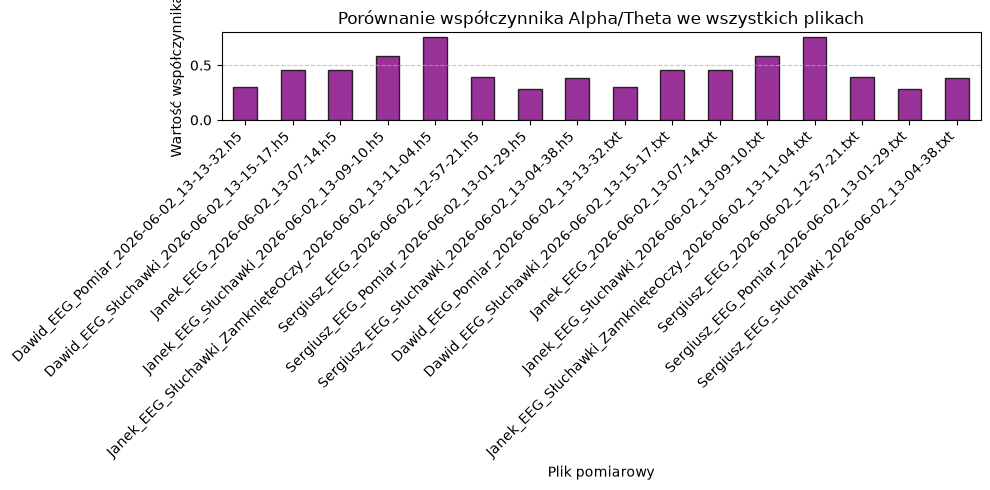

In [ ]:
if summary_data:  # Sprawdza warunkiem if, czy lista summary_data zawiera jakiekolwiek pomyślnie zebrane dane wynikowe.
    df_results = pd.DataFrame(summary_data)  # Konwertuje listę słowników na ustrukturyzowany obiekt DataFrame biblioteki Pandas.
    df_results.set_index('Nazwa pliku', inplace=True)  # Ustawia kolumnę z nazwami plików jako główny indeks (wiersze) powstałej tabeli.
    
    print("\n==============================================")
    print("ZBIORCZE PODSUMOWANIE DLA WSZYSTKICH PLIKÓW")
    print("==============================================")
    display(df_results)  # Wywołuje natywną dla Jupytera funkcję display, która renderuje tabelę danych w postaci interaktywnej i ładnej siatki.
    
    plt.figure(figsize=(10, 5))  # Przygotowuje okno pod zbiorczy wykres porównawczy o optymalnych wymiarach.
    df_results['alpha_theta_ratio'].plot(kind='bar', color='purple', alpha=0.8, edgecolor='black')  # Rysuje zbiorczy wykres słupkowy dla kolumny zawierającej współczynniki alpha_theta_ratio.
    plt.title('Porównanie współczynnika Alpha/Theta we wszystkich plikach')  # Ustala globalny tytuł dla generowanego wykresu porównawczego.
    plt.ylabel('Wartość współczynnika')
    plt.xlabel('Plik pomiarowy')
    plt.xticks(rotation=45, ha='right')  # Obraca podpisy na osi X o 45 stopni i wyrównuje je do prawej strony.
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Dokłada poziome linie siatki pomocniczej w tle wykresu o przerywanej strukturze i dużej przezroczystości.
    plt.tight_layout()  # Automatycznie koryguje marginesy okna, zapobiegając ucinaniu długich opisów osi lub etykiet słupków.
    plt.show()  # Wyświetla finalny wykres porównawczy zamykający całe badanie.
else:
    print("Brak danych do stworzenia podsumowania zbiorczego.")